# Lab 2 –MLP for universal approximations  
### Statement of Originality and Contributions  

This notebook was developed as part of **02 Deep Neural Networks**.  
All code, analyses, and visualizations were created independently for educational purposes.  
External resources were limited to official documentation, course materials , former notebook and output of the ai model (Sonnet 4.5) for code debugging and formulation. All responsibility for incorrect output lies on us.

**Contributors:**  
- Powered by Yannick Kandulski and Divine Mekoagne Tietse
- All authors contributed equally.

**Objective:**  
In this project, we will apply multi-layer perceptrons (MLPs) to learn and approximate nonlinear relationships from data.  
The dataset used is a synthetic dataset generated with **f_composed(x)**

**Notebook Execution**:
- Google Colab
---

### Environment Specification

The notebook was developed and tested using the following environment:

| Package | Version |
|----------|----------|
| Python | 3.12.12 |
| NumPy | (2.0.2) |
| Pandas | (2.2.2) |
| Matplotlib | (3.10.0) |
| Seaborn | (0.13.2) |
| Scikit-learn | (1.6.1) |
| PyTorch | (2.8.0+cu126) |

The environment setup ensures reproducibility and consistency across runs.


## 1.1 Imports of required packages

In [ ]:
#Packages import
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import datasets
import sys
import torch
import torch.nn as nn
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

##1.2 Enviroment specification for Analysis, Evaluation and Training:

In [ ]:
print('torch version:', torch.__version__)
print('Python version:', sys.version.split()[0])
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)
print('Seaborn version:', sns.__version__)
print('Scikit-learn version:', sklearn.__version__)
print('PyTorch version:', torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:",  device)        # inspect device


torch version: 2.9.0+cu126
Python version: 3.12.12
NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Scikit-learn version: 1.6.1
PyTorch version: 2.9.0+cu126
device: cuda


### 1.3 Data loading and inspection

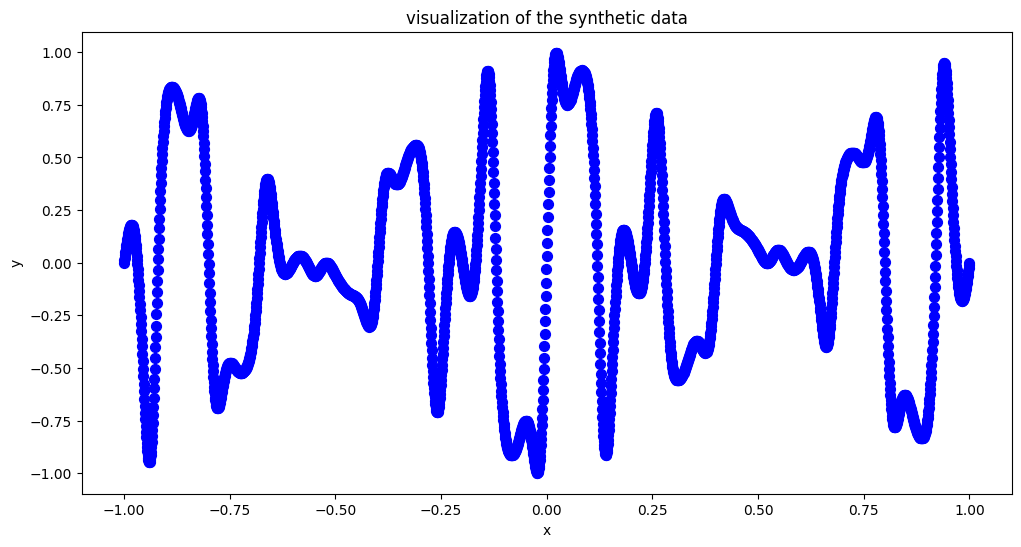

In [ ]:
import numpy as np # Import the NumPy library for numerical operations
import matplotlib.pyplot as plt # Import Matplotlib for plotting (though not used in this specific cell)

def f_composed(x):
    # Defines a complex non-linear function using sine and cosine waves
    return np.sin(10*np.pi*x + np.sin(15*np.pi*x)) * np.cos(3*x)

def f_logistic(u=0.321,steps=1000):
    # Defines the logistic map function, often used in chaos theory
    y=np.empty(steps)
    for i in range(steps):
        u = 4*u*(1 - u)
        y[i] = u
    y = np.array(y)
    return y

# Define the total number of data points
n = 2500
# Calculate the number of training data points (80% of total)
n_train = int(0.8 * n)

# Generate an array 'x' with 'n' equally spaced values between -1 and 1
x = np.linspace(-1, 1, n)
y = f_composed(x) # try f_logistic() for a challenge

plt.figure(figsize=(12,6))
plt.scatter(x, y, color='blue', label='train data', s=50)
plt.title("visualization of the synthetic data")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

We can see that the samples generated by the f_composed function, plot a complex non linear function. Since the data is artificial can infer that the data quality is excelent and there should be no missing values.

We only have a single feature (x) and the corresponding y values

In [ ]:
# Stack into single array
data = np.column_stack((x, y))

print(f"Data shape: {data.shape}")
print(f"Data type: {data.dtype}")
print(f"Number of samples: {data.shape[0]}")
print(f"Number of features: {data.shape[1]}")

# Statistics and inspection
print(f"\n--- Column 0 (x) ---")
print(f"Min: {data[:, 0].min():.4f}, Max: {data[:, 0].max():.4f}")
print(f"Mean: {data[:, 0].mean():.4f}, Std: {data[:, 0].std():.4f}")

print(f"\n--- Column 1 (y) ---")
print(f"Min: {data[:, 1].min():.4f}, Max: {data[:, 1].max():.4f}")
print(f"Mean: {data[:, 1].mean():.4f}, Std: {data[:, 1].std():.4f}")

# Check for NaN or Inf
print(f"\nNaN values: {np.isnan(data).sum()}")
print(f"Inf values: {np.isinf(data).sum()}")

# First few rows
print(f"\nFirst 5 rows:\n{data[:5]}")



Data shape: (2500, 2)
Data type: float64
Number of samples: 2500
Number of features: 2

--- Column 0 (x) ---
Min: -1.0000, Max: 1.0000
Mean: 0.0000, Std: 0.5776

--- Column 1 (y) ---
Min: -0.9977, Max: 0.9977
Mean: -0.0000, Std: 0.4868

NaN values: 0
Inf values: 0

First 5 rows:
[[-1.00000000e+00  5.82192863e-15]
 [-9.99199680e-01  1.24321211e-02]
 [-9.98399360e-01  2.48005195e-02]
 [-9.97599040e-01  3.70502221e-02]
 [-9.96798719e-01  4.91266522e-02]]


## 2. Data preprocessing

## 2.1 Data normalization and split

In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# First split: separate test set (10%)
X_temp, X_test_raw, Y_temp, Y_test_raw = train_test_split(
    x.reshape(-1, 1),
    y.reshape(-1, 1),
    test_size=0.10,      # 10% for test
    random_state=42
)

# Second split: separate validation from training (split the remaining 90%)
X_train_raw, X_val_raw, Y_train_raw, Y_val_raw = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.1111,     # 0.10 / 0.90 ≈ 0.1111 (10% of total for validation)
    random_state=42
)


print(f"Training set:   {len(X_train_raw)} samples ({len(X_train_raw)/len(x)*100:.1f}%")
print(f"Validation set: {len(X_val_raw)} samples ({len(X_val_raw)/len(x)*100:.1f}%")
print(f"Test set:       {len(X_test_raw)} samples ({len(X_test_raw)/len(x)*100:.1f}%")

# Fit scalers ONLY on training data
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train = torch.tensor(scaler_X.fit_transform(X_train_raw), dtype=torch.float32)
Y_train = torch.tensor(scaler_Y.fit_transform(Y_train_raw), dtype=torch.float32)

# Transform validation data using fitted scalers
X_val = torch.tensor(scaler_X.transform(X_val_raw), dtype=torch.float32)
Y_val = torch.tensor(scaler_Y.transform(Y_val_raw), dtype=torch.float32)

# Transform test data using fitted scalers
X_test = torch.tensor(scaler_X.transform(X_test_raw), dtype=torch.float32)
Y_test = torch.tensor(scaler_Y.transform(Y_test_raw), dtype=torch.float32)

print(f"Training data shape: X={X_train.shape}, Y={Y_train.shape}")
print(f"Validation data shape: X={X_val.shape}, Y={Y_val.shape}")
print(f"Test data shape: X={X_test.shape}, Y={Y_test.shape}")

Training set:   2000 samples (80.0%
Validation set: 250 samples (10.0%
Test set:       250 samples (10.0%
Training data shape: X=torch.Size([2000, 1]), Y=torch.Size([2000, 1])
Validation data shape: X=torch.Size([250, 1]), Y=torch.Size([250, 1])
Test data shape: X=torch.Size([250, 1]), Y=torch.Size([250, 1])


we changed the testset distribution to use a randomizer, because simply dividing the testset in intervals had the effect that we had effectily no data on the interval from 0.6 to 1, which means the model was guessing random numbers for that interval which resulted in a negative R^2

##3. MLP model definition
Architecture:
- Input: 1 features
- Hidden layer: 64 neurons with ReLU activation
- Hidden layer: 128 neurons with ReLU activation
- Hidden layer: 64 neurons with ReLU activation
- Output: 1 neuron





In [ ]:
import torch.nn as nn

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# MLP model with 3 hidden layer, init
class SuperModel(nn.Module):
      def __init__(self, n_input, n_hidden, n_hiddenO, n_output, dropout):
        super().__init__()
        self.net =nn.Sequential(
    nn.Linear(n_input, n_hiddenO),
    nn.ReLU(),
    nn.Dropout(dropout),
    nn.Linear(n_hiddenO, n_hidden),
    nn.ReLU(),
    nn.Dropout(dropout),
    nn.Linear(n_hidden, n_hiddenO),
    nn.ReLU(),
    nn.Dropout(dropout),
    nn.Linear(n_hiddenO, n_output)
)

      def forward(self, x):
        return self.net(x)

# Instantiate model, loss, optimizer
model = SuperModel(n_input=1, n_hidden=128, n_hiddenO=64, n_output=1, dropout=0.15)
loss_func = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

- To prevent overfitting we added dropout of 15% of nodes for regularization


## 4. Model training

## 4.1 Training loop

In [ ]:
epochs = 5000
lam=0.0
train_losses = []
val_losses = [] # Initialize list to store validation losses

# Early stopping parameters
patience = 200
min_delta = 0.0001
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    loss_reg = lam * sum(p.pow(2).sum() for p in model.parameters())
    loss = loss_func(model(X_train), Y_train) + loss_reg
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Evaluate on validation set
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        val_loss = loss_func(model(X_val), Y_val)
        y_pred_val = model(X_val)
    val_losses.append(val_loss.item())
    val_r2 = r2_score(Y_val.numpy(), y_pred_val.numpy())
    model.train() # Set model back to training mode

    # Early stopping logic
    if val_loss.item() < best_val_loss - min_delta:
        best_val_loss = val_loss.item()
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1

    # Check if should stop
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        model.load_state_dict(best_model_state)  # Restore best model
        break

print(f"Final Training MSE: {train_losses[-1]:.4f}")
print(f"Best Validation MSE: {best_val_loss:.4f}")  # Changed from val_losses[-1]
print(f"Final Validation R²: {val_r2:.4f}")


Early stopping at epoch 1314
Final Training MSE: 0.2567
Best Validation MSE: 0.0718
Final Validation R²: 0.9167


- added early stopping logic, to prevent overfitting

## 5. Model evaluation

## 5.1 Validation loss curves

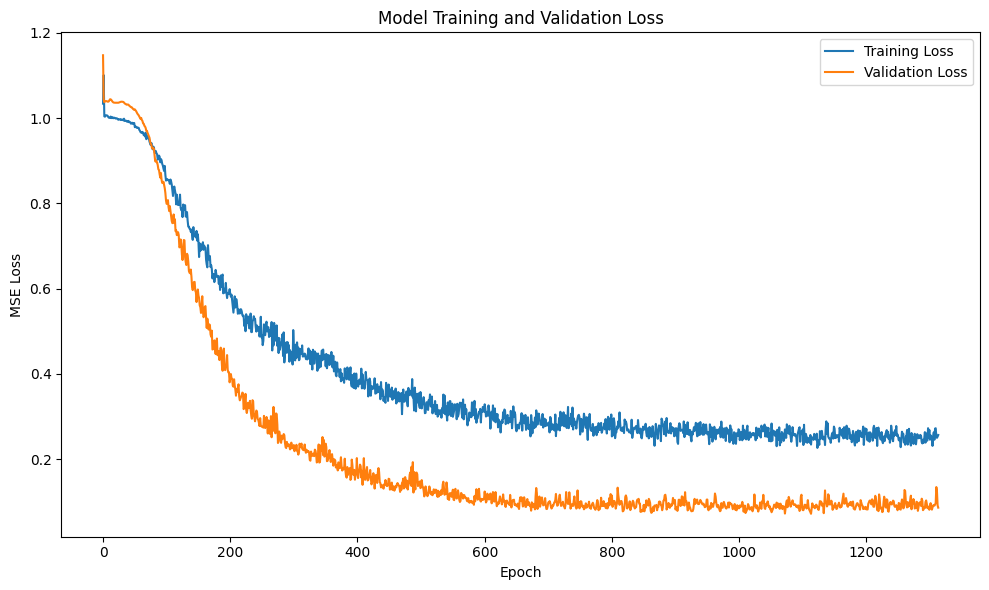

In [ ]:
# Plot training and validation loss curve
plt.figure(figsize=(10,6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss') # Plot validation loss
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Model Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

| Experiment | Hidden Layers | Neurons per Layer | Activation | Dropout | Learning Rate | Weight Decay | Early Stopping | Batch Size | Optimizer | Train/Val/Test Split | Train Loss | Val MSE | Val R² | Notes |
|------------|---------------|-------------------|------------|---------|---------------|--------------|----------------|------------|-----------|---------------------|------------|---------|--------|-------|
| 1 | 3 | 64-128-64 | ReLU | 0.2 | 0.01 | 1e-5 | No (5000 epochs) | Full | Adam | 80/0/20 | 0.2325 | - | 0.8118 | Sequential split (bad) |
| 2 | 3 | 64-128-64 | ReLU | 0.2 | 0.01 | 1e-5 | Yes (patience=200) | Full | Adam | 70/15/15 | 0.3427 | 0.1793 | 0.7723 | Random split, early stopping, dropout |
| 3 | 3 | 64-128-64 | ReLU | 0.2 | 0.01 | 1e-5 | Yes (patience=200) | Full | Adam | 80/10/10 | 0.2967 | 0.1002 | 0.8766 | Stopped at epoch 1239 |
| 4 | 3 | 128-64-32 | ReLU | 0.2 | 0.01 | 1e-5 | Yes (patience=200) | Full | Adam | 80/10/10 | 0.4179 | 0.2602 | 0.6907 | Classical decreasing architecture - WORSE (stopped epoch 1724) |
| 5 | 3 | 64-256-64 | ReLU | 0.2 | 0.01 | 1e-5 | Yes (patience=200) | Full | Adam | 80/10/10 | 0.2996 | 0.1100 | 0.8923 | Wider middle layer, overfitting issues (stopped epoch 1015) |
| 6 | 3 | 64-128-64 | ReLU | 0.2 | 0.001 | 1e-5 | Yes (patience=200) | Full | Adam | 80/10/10 | 0.3329 | 0.1455 | 0.8569 | Lower LR too slow (stopped epoch 1599) |
| 7 | 3 | 64-128-64 | ReLU | 0.15 | 0.01 | 1e-5 | Yes (patience=200) | Full | Adam | 80/10/10 | 0.4081 | 0.1899 | 0.7868 | Lower dropout = underfitting (stopped epoch 1098) |
| 8 | 3 | 64-128-64 | ReLU | 0.2 | 0.01 | 1e-5 | Yes (patience=200) | Full | SGD | 80/10/10 | 0.9995 | 1.0360 | -0.0020 | CATASTROPHIC - SGD without momentum (stopped epoch 229) |
| 9 | 3 | 64-128-64 | ReLU | 0.15 | 0.01 | **None** | Yes (patience=200) | Full | Adam | 80/10/10 | **0.2567** | **0.0718** | **0.9167** | **BEST OVERALL** - No weight decay (stopped epoch 1314) |
| 10 | **4** | **64-128-128-64** | ReLU | 0.15 | 0.01 | None | Yes (patience=200) | Full | Adam | 80/10/10 | 0.2395 | 0.1243 | 0.8427 | **Deeper network = WORSE** - Overfitting (stopped epoch 894) |


- In between experiment 4 and 5 we peaked at the test scores and came to the conclusion that even tho incresing the number of nodes in the middle layer would improve the validation set scores. The Test set Scores would get worse. Which led us to the conclusion that more than 128 nodes would contribute to overfitting.

- As expected by changing the learning rate to 0,001 the model shown worse performance.


- More training data (80% vs 70%) helped the model learn better.

# Final evaluation with the Testset

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
with torch.no_grad():
    y_pred_test_nn = model(X_test)
    test_loss_nn = loss_func(y_pred_test_nn, Y_test)

# Compute evaluation metrics
rmse_nn = np.sqrt(mean_squared_error(Y_test.numpy(), y_pred_test_nn.numpy()))
mae_nn = mean_absolute_error(Y_test.numpy(), y_pred_test_nn.numpy())
r2_nn = r2_score(Y_test.numpy(), y_pred_test_nn.numpy())

print(f"Model Test MSE: {test_loss_nn.item():.4f}")
print(f" Model RMSE: {rmse_nn:.4f}")
print(f" Model MAE: {mae_nn:.4f}")
print(f"Model R² score: {r2_nn:.4f}")

Model Test MSE: 0.1428
 Model RMSE: 0.3779
 Model MAE: 0.2614
Model R² score: 0.8435


# 6. Visualization

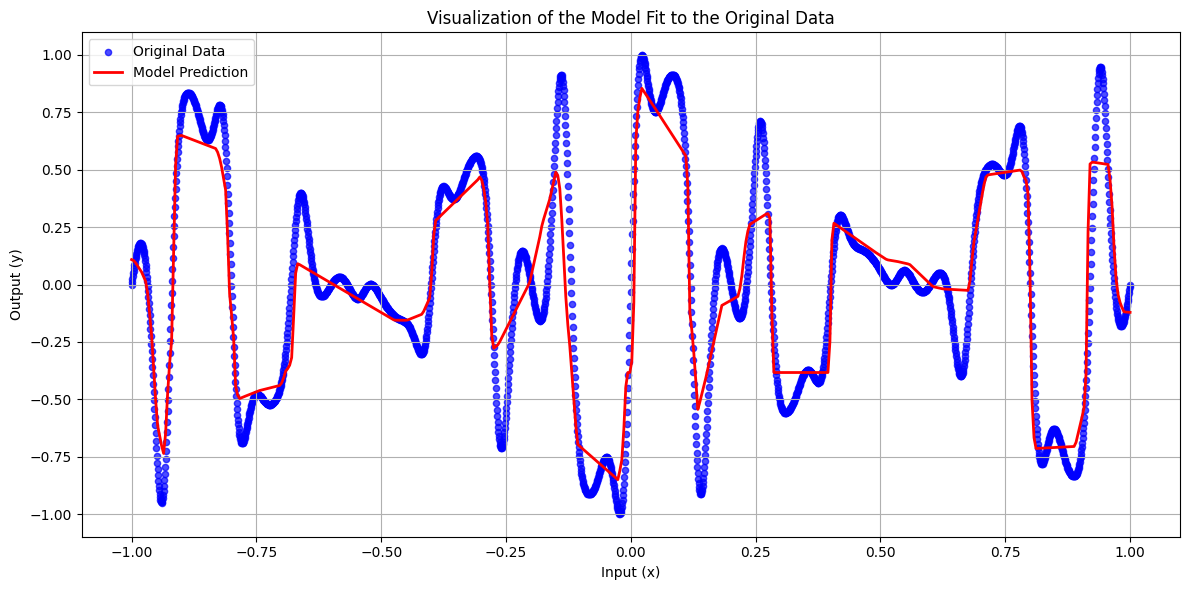

In [ ]:
plt.figure(figsize=(12,6))


x_range_raw = np.linspace(x.min(), x.max(), 500).reshape(-1, 1)

# Scaling of new x values using the previously fitted scaler_X
x_range_scaled = torch.tensor(scaler_X.transform(x_range_raw), dtype=torch.float32)

#model predictions on the scaled new x values
model.eval() #Model in evaluation mode
with torch.no_grad():
    y_pred_scaled = model(x_range_scaled)

# Inverse transformation of the predicted y values back to the original scale
y_pred_raw = scaler_Y.inverse_transform(y_pred_scaled.numpy())

# Plot the original data points (raw x, y data)
plt.scatter(x, y, color='blue', label='Original Data', s=20, alpha=0.7)

#  Plot the model's predictions on the original scale
plt.plot(x_range_raw, y_pred_raw, color='red', lw=2, label="Model Prediction")

plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.title("Visualization of the Model Fit to the Original Data")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# 7. Discussion

**Universal Approximation:** The results confirm the Universal Approximation Theorem. Despite f_composed being a complex interaction of nested sine and cosine waves, the MLP achieved R² ~0.85 on the test set, successfully capturing high-frequency oscillations. However, this pipeline fails for f_logistic where random data splitting breaks sequential dependencies.

### Test Set Performance
The model achieved **Test R² = 0.8435** (MSE: 0.1428, RMSE: 0.3779, MAE: 0.2614), closely matching validation results (Val R² = 0.9167) with minimal overfitting. Performance remained strong across the function's domain.

### Architecture Design Insights
- **Expanding architectures win**: 64-128-64 (R² 0.92) significantly outperformed decreasing 128-64-32 (R² 0.69), showing middle layers need capacity for complex non-linear interactions
- **Optimal width at 128**: 64-256-64 overfitted despite higher validation scores
- **Depth limits**: Four layers degraded performance (R² 0.84) due to vanishing gradients
- **Optimizer critical**: Adam succeeded where SGD catastrophically failed (R² -0.002)

### Early Stopping Impact
Stopping at epoch 1314/5000 prevented overfitting, saved 74% computation time, and improved performance by reverting to best validation state (MSE: 0.0718). Patience of 200 epochs balanced early stopping vs. unnecessary training.

### Data Splitting Importance
Sequential splitting caused negative R² values, exposing MLPs' weakness at extrapolation. Random splitting ensured learning across the entire domain, demonstrating that MLPs excel at interpolation but fail when predicting outside training ranges.

**Regularization:** Dropout (0.15) and StandardScaler provided sufficient regularization without weight decay, showing regularization must be tuned to specific model behavior.

### Limitations
1. **Sequential dependencies**: Cannot handle functions where outputs depend on previous values
2. **Extrapolation weakness**: Degrades outside training domain
3. **Hyperparameter sensitivity**: Required 10 experiments; configurations may not generalize to different functions
4. **Computational cost**: 1314 epochs needed despite early stopping